# Week 9 - Multivariate Analysis, part 2

# 1. Lesson - no lesson this week

# 2. Weekly graph question

The graph below plots the first two principal component scores in a scatter plot.  What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?  What does that mean about their values in series_1, series_2, and series_3?  It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.

Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?

[0.79916477 0.18990532 0.01092991]
[[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]


Text(0, 0.5, 'Second Principal Component Score')

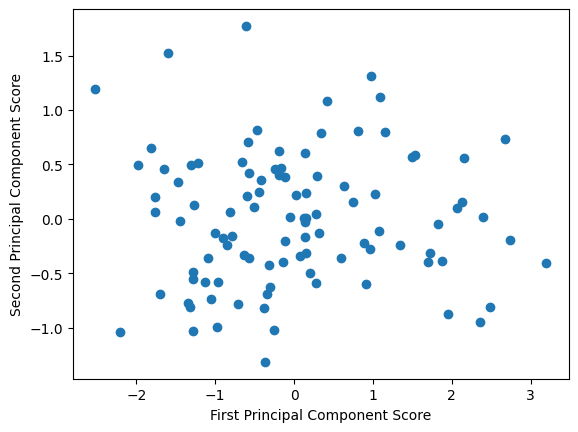

In [1]:
import numpy as np
import pandas as pd
from sklearn import decomposition
import matplotlib.pyplot as plt

np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

first_principal_component_score = df.dot(pca3.components_[0])
second_principal_component_score = df.dot(pca3.components_[1])
plt.scatter(first_principal_component_score, second_principal_component_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")

With the 3 outliers in the upper left hand corner of the plot, you can see they are among the highest second principle component (PC) score, while also being all negative in thge first PC score making them low on the first PC score. <br>
One thing that appears to stand out is that series 3 may be the plots with the largest variance out of the three series. I attribute this to the large second PC scores typically indicating large variance with series 3. <br>
I am unsure what to draw from series 1 and series 2 as they seem to not contirbute to a higher than average second PC score. <br>


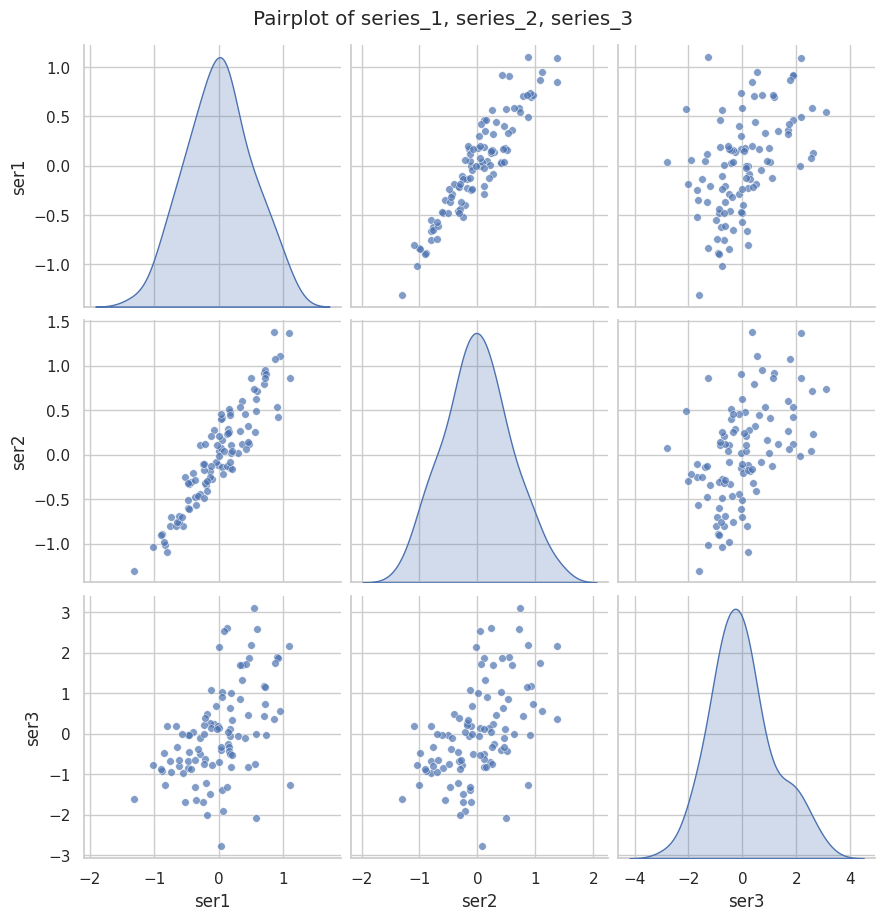

In [14]:
import seaborn as sns

sns.set_theme(style='whitegrid')
g = sns.pairplot(df, diag_kind='kde', height=3,
plot_kws={'s': 30, 'alpha': 0.7})
g.figure.suptitle('Pairplot of series_1, series_2, series_3', y=1.02)
plt.show()

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:
Draw heatmaps.

Draw bubble plots.

Perform Principal Component Analysis to find out the directions in which the data varies.  Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?

Try performing linear regression analysis using different sets of features.  Which features seem most likely to be useful to predict other features?

Conclusions:
Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

Try using your correlation information from previous weeks to help choose features for linear regression.

In [25]:
df2 = pd.read_csv('/workspaces/Module-B-semester-2/credit_risk_dataset.csv', sep=',')
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB


In [26]:
df2_clean = df2.copy()
df2_clean.dropna(inplace=True)
df2_clean.drop_duplicates(inplace=True)
df2_clean.info()

<class 'pandas.DataFrame'>
Index: 28501 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  28501 non-null  int64  
 1   person_income               28501 non-null  int64  
 2   person_home_ownership       28501 non-null  str    
 3   person_emp_length           28501 non-null  float64
 4   loan_intent                 28501 non-null  str    
 5   loan_grade                  28501 non-null  str    
 6   loan_amnt                   28501 non-null  int64  
 7   loan_int_rate               28501 non-null  float64
 8   loan_status                 28501 non-null  int64  
 9   loan_percent_income         28501 non-null  float64
 10  cb_person_default_on_file   28501 non-null  str    
 11  cb_person_cred_hist_length  28501 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 2.8 MB


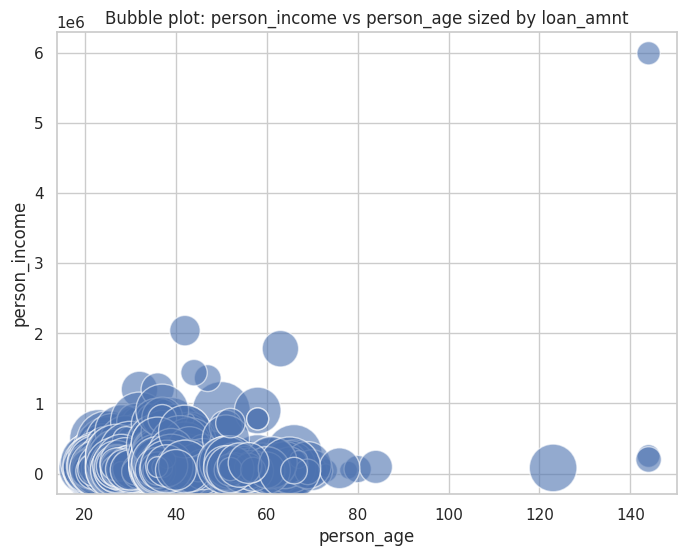

In [ ]:
#Bubble Plot:

x_col = "person_age"
y_col = "person_income"
size_col = "loan_amnt"
color_col = 'default'

plot_df = df2_clean[[x_col, y_col, size_col]].dropna()

sizes = plot_df[size_col].values

sizes_scaled = 2000 * (sizes - sizes.min()) / max(1e-9, (sizes.max() - sizes.min())) + 20

plt.figure(figsize=(8, 6))
plt.scatter(plot_df[x_col], plot_df[y_col], s=sizes_scaled, alpha=0.6, edgecolors='w')
plt.xlabel(x_col)
plt.ylabel(y_col)
plt.title(f'Bubble plot: {y_col} vs {x_col} sized by {size_col}')
plt.grid(True)
plt.show()

[9.90530119e-01 9.46987091e-03 9.82333637e-09]
[[ 1.81193967e-05  9.99631787e-01  2.71346592e-02]
 [ 6.83565463e-06 -2.71346593e-02  9.99631787e-01]
 [ 1.00000000e+00 -1.79272418e-05 -7.32480131e-06]]


Text(0, 0.5, 'Second Principal Component Score')

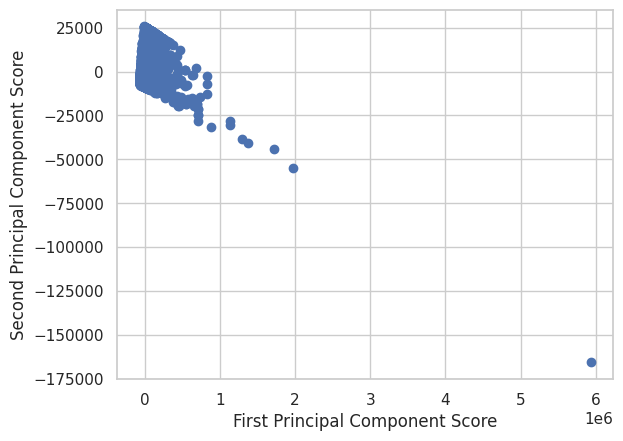

In [30]:
#Principal Component analysis:

series_1 = df2_clean["person_age"]
series_2 = df2_clean["person_income"]
series_3 = df2_clean["loan_amnt"]
df3 = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df3 = df3 - df3.mean()

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df3)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

first_principal_component_score = df3.dot(pca3.components_[0])
second_principal_component_score = df3.dot(pca3.components_[1])
plt.scatter(first_principal_component_score, second_principal_component_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")

After uploading my data, it appears I need to do further cleaning outside of just duplicate values and null values being removed. <br>
I have cleaned the data, but uploading it fresh requires further cleaning. My data seems to be currupted by some outliers that are throwing off my analysis. <br>
Will need to go back and clean this data set of outliers and likely pick different numeric features for analysis. <br>

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 136-150 of the Storytelling With Data book as best you can. ("The power of super-categories" to the end of chapter 5). You do not have to get the exact data values right, just the overall look and feel.

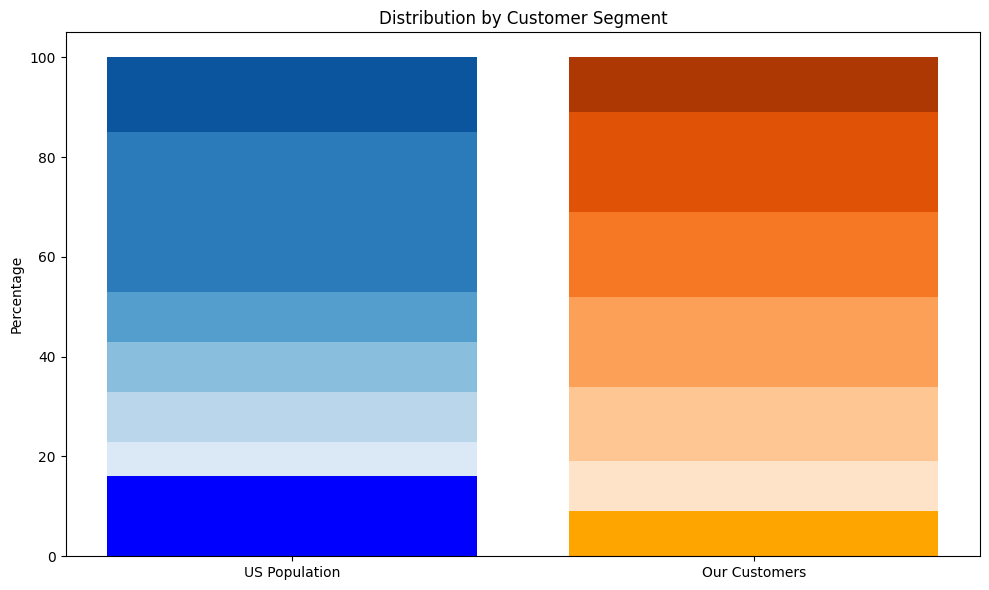

In [2]:
segments = ['Segment 1', 'Segment 2', 'Segment 3', 'Segment 4', 'Segment 5', 'Segment 6', 'Segment 7']
us_population = [16, 7, 10, 10, 10, 32, 15]
our_customers = [9, 10, 15, 18, 17, 20, 11]

y_values = np.array([us_population, our_customers])

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar('US Population', y_values[0, 0], color='blue')
bottom = y_values[0, 0]
for i in range(1, len(segments)):
    ax.bar('US Population', y_values[0, i], bottom=bottom, color=plt.cm.Blues(i / len(segments)))
    bottom += y_values[0, i]

ax.bar('Our Customers', y_values[1, 0], color='orange')
bottom = y_values[1, 0]
for i in range(1, len(segments)):
    ax.bar('Our Customers', y_values[1, i], bottom=bottom, color=plt.cm.Oranges(i / len(segments)))
    bottom += y_values[1, i]

ax.set_ylabel('Percentage')
ax.set_title('Distribution by Customer Segment')

plt.tight_layout()
plt.show()